In [2]:
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

### 图像读取与展示

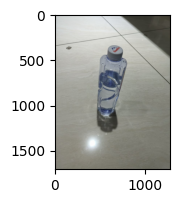

In [14]:
# 读取图像
image = cv2.imread('./assets/1.jpg')  # 替换为你图像的路径

# 检查图像是否加载成功
if image is None:
    print("Error: Unable to load image.")
else:
    # 转换 BGR 到 RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(2, 2))
    plt.imshow(image_rgb)

### 视频播放

```python
import cv2
import numpy as np

vc = cv2.VideoCapture("./assets/test.mp4")

if vc.isOpened():
    open, frame = vc.read()
else:
    open = False

while open:
    ret, frame = vc.read()
    if frame is None:
        break
    if ret == True:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        cv2.imshow('result', gray)
        # 每帧等待时间
        if cv2.waitKey(100) & 0xFF == 27: # 在 虚拟机上，而不是控制台，退出键 ESC
            break
vc.release()
cv2.destroyAllWindows()
```

### 图像的基础操作

原图像的shape: (1706, 1279, 3)
灰度图的shape: (1706, 1279)
图像的类型: <class 'numpy.ndarray'>
图像的大小: 6545922


(-0.5, 1278.5, 1705.5, -0.5)

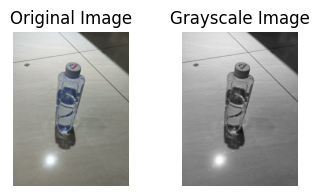

In [13]:
# 读取图像
img = cv2.imread('./assets/1.jpg')  # 替换为你图像的路径

# 打印原始图像的 shape
print("原图像的shape:", img.shape)

# 转换成灰度图
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 打印灰度图像的 shape
print("灰度图的shape:", gray_img.shape)

# 打印图像的类型
print("图像的类型:", type(img))

# 打印图像的大小
print("图像的大小:", img.size)

# 使用 matplotlib 显示原图像和灰度图
# 显示原图（BGR 转换为 RGB）
plt.figure(figsize=(4, 2))

# 原图
plt.subplot(1, 2, 1)  # 1 行 2 列的第 1 个图
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # BGR 转 RGB
plt.title("Original Image")
plt.axis('off')  # 关闭坐标轴

# 显示灰度图
plt.subplot(1, 2, 2)  # 1 行 2 列的第 2 个图
plt.imshow(gray_img, cmap='gray')  # 显示灰度图
plt.title("Grayscale Image")
plt.axis('off')  # 关闭坐标轴


### 颜色操作

B channel shape: (1706, 1279)


Text(0.5, 1.0, 'Blue Channel')

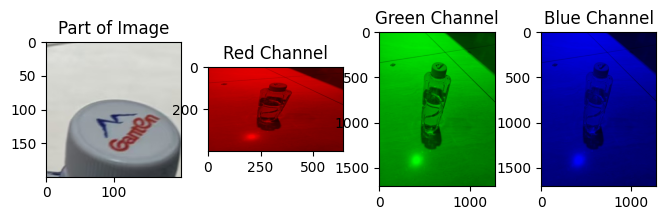

In [24]:
plt.figure(figsize=(8, 2))
# 读取图像
img = cv2.imread('./assets/1.jpg')  # 替换为你图像的路径

# 显示原图的部分
part = img[250:450, 550:750]

# 使用 matplotlib 显示部分图像
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(part, cv2.COLOR_BGR2RGB))
plt.title('Part of Image')

# 颜色通道提取，注意不是 rgb
b, g, r = cv2.split(img)
print("B channel shape:", b.shape)

# 只保留 R 通道
cur_img = img.copy()
cur_img[:,:,0] = 0
cur_img[:,:,1] = 0
cur_img_resized = cv2.resize(cur_img, (640, 400))

# 显示只保留 R 通道的图像
plt.subplot(1, 4, 2)
plt.imshow(cv2.cvtColor(cur_img_resized, cv2.COLOR_BGR2RGB))
plt.title('Red Channel')

# 只保留 G 通道
cur_img = img.copy()
cur_img[:,:,0] = 0
cur_img[:,:,2] = 0

# 显示只保留 G 通道的图像
plt.subplot(1, 4, 3)
plt.imshow(cv2.cvtColor(cur_img, cv2.COLOR_BGR2RGB))
plt.title('Green Channel')

# 只保留 B 通道
cur_img = img.copy()
cur_img[:,:,1] = 0
cur_img[:,:,2] = 0

# 显示只保留 B 通道的图像
plt.subplot(1, 4, 4)
plt.imshow(cv2.cvtColor(cur_img, cv2.COLOR_BGR2RGB))
plt.title('Blue Channel')


### 边界填充

Text(0.5, 1.0, 'constant')

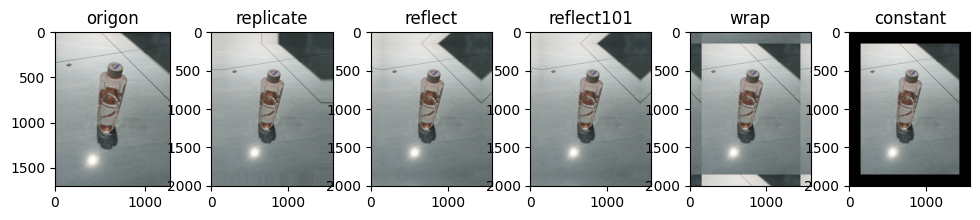

In [ ]:
img = cv2.imread('./assets/1.jpg')

top_size, bottom_size, left_size, right_size = (150, 150, 150, 150)

plt.figure(figsize=(12, 2))

plt.subplot(1, 6, 1)
plt.imshow(img)
plt.title("origon")

replicate = cv2.copyMakeBorder(img, top_size, bottom_size, left_size, right_size, borderType=cv2.BORDER_REPLICATE)
plt.subplot(1, 6, 2)
plt.imshow(replicate)
plt.title("replicate")

replicate = cv2.copyMakeBorder(img, top_size, bottom_size, left_size, right_size, borderType=cv2.BORDER_REFLECT)
plt.subplot(1, 6, 3)
plt.imshow(replicate)
plt.title("reflect")

replicate = cv2.copyMakeBorder(img, top_size, bottom_size, left_size, right_size, borderType=cv2.BORDER_REFLECT101)
plt.subplot(1, 6, 4)
plt.imshow(replicate)
plt.title("reflect101")

replicate = cv2.copyMakeBorder(img, top_size, bottom_size, left_size, right_size, borderType=cv2.BORDER_WRAP)
plt.subplot(1, 6, 5)
plt.imshow(replicate)
plt.title("wrap")

replicate = cv2.copyMakeBorder(img, top_size, bottom_size, left_size, right_size, borderType=cv2.BORDER_CONSTANT, value = 0)
plt.subplot(1, 6, 6)
plt.imshow(replicate)
plt.title("constant")

### 数值计算

(<Axes: >, <matplotlib.image.AxesImage at 0x7f8d0be1dd60>)

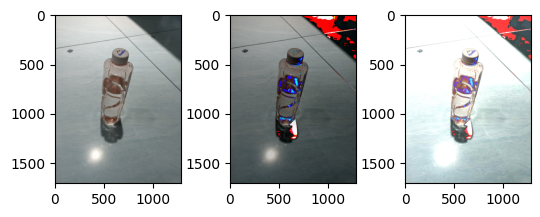

In [ ]:
img = cv2.imread('./assets/1.jpg')

plt.subplot(231), plt.imshow(img)

# 对 R、G 和 B 通道的所有像素值都进行了加 200 的操作
# 如果某个像素值超过 255，会发生 溢出，即该值会“环绕”并重新从 0 开始
img2 = img + 200
plt.subplot(232), plt.imshow(img2)

# 如果越界了，则取最大值 255
img3 = cv2.add(img, img2)
plt.subplot(233), plt.imshow(img3)

### 图像融合

(400, 640, 3)
(400, 640, 3)


Text(0.5, 1.0, '3x x')

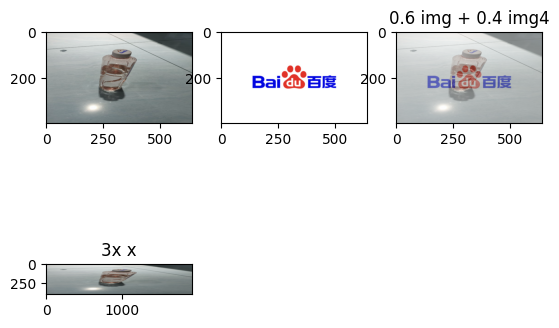

In [29]:
img = cv2.imread('./assets/1.jpg')
img4 = cv2.imread('./assets/4.jpg')


img = cv2.resize(img, (640, 400))
img4 = cv2.resize(img4, (640, 400))
print(img.shape)
print(img4.shape)

plt.subplot(231), plt.imshow(img)
plt.subplot(232), plt.imshow(img4)

img5 = cv2.addWeighted(img, 0.6, img4, 0.4, 0)
plt.subplot(233), plt.imshow(img5)
plt.title("0.6 img + 0.4 img4")

res = cv2.resize(img, (0, 0), fx = 3, fy = 1)
plt.subplot(234), plt.imshow(res)
plt.title("3x x")